# Experiment 2 Extension — Robust Open-Set Cotton Disease Classifier

This extension turns the seven-class EfficientNetB0 classifier into a safer open-set system. It keeps the six supported cotton classes and the operational `Unclassified` class, then adds three protections against arbitrary inputs:

1. A diverse `Unclassified` training set containing non-cotton leaves, flowers, animals, objects, vehicles, faces, scenes, and other non-plant images.
2. A separate **plant/leaf gate** trained to distinguish plant-like images from non-plant images before disease classification.
3. A validation-calibrated confidence rejection rule that can return `Unclassified` when the disease model is uncertain.

The final decision never maps a rejected non-plant image to `Healthy` or another disease class. The system reports source-specific behavior so weaknesses are visible rather than hidden by one aggregate score.

> **Kaggle requirement:** enable Internet access for the first run so `tf.keras.datasets.cifar10.load_data()` can download CIFAR-10. This version deliberately does not use TFDS or the unavailable PlantVillage/Beans Mendeley endpoints.


## 1. Reliable unknown-image source

This runnable version uses **CIFAR-10 through `tf.keras.datasets.cifar10.load_data()`** for the non-plant `Unclassified` examples. CIFAR-10 contains airplanes, automobiles, birds, cats, deer, dogs, frogs, horses, ships, and trucks. It is not a perfect deployment proxy because its images are only 32×32 pixels, but it is a stable, directly supported Keras download and avoids the HTTP 403 failures from the PlantVillage and Beans Mendeley endpoints.

The `Unclassified` label is operational: it means “not one of the six supported cotton classes,” not one biological category. The notebook reports source-specific unknown performance and leaves a clearly documented extension point for adding field plant images later through a local Kaggle input folder.


In [1]:
# If needed outside Kaggle, uncomment:
# %pip install -q tensorflow-datasets scikit-learn seaborn pillow pandas matplotlib

import os, json, hashlib, random, shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFile
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score

ImageFile.LOAD_TRUNCATED_IMAGES = True
print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
SEED = 123
random.seed(SEED); np.random.seed(SEED); tf.keras.utils.set_random_seed(SEED)
try: tf.config.experimental.enable_op_determinism()
except Exception: pass

COTTON_ROOT = Path("/kaggle/input/datasets/dhamur/cotton-plant-disease/Cotton leaves/40 Images")
WORKING_DIR = Path("/kaggle/working/exp02_robust_open_set")
UNKNOWN_ROOT = WORKING_DIR / "unknown_sources"
WORKING_DIR.mkdir(parents=True, exist_ok=True); UNKNOWN_ROOT.mkdir(parents=True, exist_ok=True)
IMAGE_SIZE=(256,256); CHANNELS=3; BATCH_SIZE=32
SUPPORTED_CLASSES=["Aphids","Army worm","Bacterial blight","Healthy","Powdery mildew","Target spot"]
CLASS_NAMES=SUPPORTED_CLASSES+["Unclassified"]
NUM_SUPPORTED_CLASSES=6; UNKNOWN_INDEX=6; NUM_CLASSES=7
EXPECTED_COTTON_TOTAL=4788; COTTON_TRAIN=3840; COTTON_VAL=480; COTTON_TEST=468
UNKNOWN_TRAIN=800; UNKNOWN_VAL=400; UNKNOWN_TEST=400
VALID_EXTENSIONS={".jpg",".jpeg",".png",".bmp",".gif",".webp"}


## 2. Build the supported cotton split

The six cotton categories use the 4,788-image main dataset and a stratified file-level split of 3,840 training, 480 validation, and 468 test images.


In [3]:
records=[]
for label,name in enumerate(SUPPORTED_CLASSES):
    folder=COTTON_ROOT/name
    if not folder.is_dir(): raise FileNotFoundError(folder)
    for p in sorted(folder.rglob("*")):
        if p.is_file() and p.suffix.lower() in VALID_EXTENSIONS:
            records.append({"filepath":str(p),"source":"cotton","source_group":f"cotton::{name}","class_name":name,"label":label,"is_plant":1})
cotton_df=pd.DataFrame(records).sort_values("filepath").reset_index(drop=True)
assert len(cotton_df)==EXPECTED_COTTON_TOTAL
cotton_dev,cotton_test=train_test_split(cotton_df,test_size=COTTON_TEST,random_state=SEED,stratify=cotton_df.label)
cotton_train,cotton_val=train_test_split(cotton_dev,test_size=COTTON_VAL,random_state=SEED,stratify=cotton_dev.label)
cotton_train=cotton_train.sort_values("filepath").reset_index(drop=True)
cotton_val=cotton_val.sort_values("filepath").reset_index(drop=True)
cotton_test=cotton_test.sort_values("filepath").reset_index(drop=True)
assert [len(x) for x in [cotton_train,cotton_val,cotton_test]]==[COTTON_TRAIN,COTTON_VAL,COTTON_TEST]
print({"train":len(cotton_train),"validation":len(cotton_val),"test":len(cotton_test)})


{'train': 3840, 'validation': 480, 'test': 468}


## 3. Materialize diverse non-plant unknown images

CIFAR-10 is loaded with Keras rather than TFDS. The official training split supplies the unknown training and validation images, and the official test split supplies the unknown test images. The split is deterministic and source-separated.


In [4]:
def save_png(array, path):
    Image.fromarray(np.asarray(array).astype(np.uint8)).convert("RGB").save(path, format="PNG")


def materialize_cifar10_unknowns(out_root, seed=SEED):
    """Materialize deterministic non-plant unknowns without TFDS/Mendeley."""
    (x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
    y_train = y_train.reshape(-1)
    y_test = y_test.reshape(-1)

    rng = np.random.default_rng(seed)
    train_order = rng.permutation(len(x_train))
    test_order = rng.permutation(len(x_test))
    train_ids = train_order[:UNKNOWN_TRAIN]
    val_ids = train_order[UNKNOWN_TRAIN:UNKNOWN_TRAIN + UNKNOWN_VAL]
    test_ids = test_order[:UNKNOWN_TEST]

    cifar_names = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]
    animal_labels = {2, 3, 4, 5, 6, 7}
    rows = []

    def write_split(images, labels, ids, split):
        split_dir = out_root / "cifar10" / split
        split_dir.mkdir(parents=True, exist_ok=True)
        for ordinal, index in enumerate(ids):
            image = images[index]
            label_id = int(labels[index])
            digest = hashlib.sha256(image.tobytes()).hexdigest()
            path = split_dir / f"{ordinal:05d}_{digest[:12]}.png"
            save_png(image, path)
            subtype = "animal" if label_id in animal_labels else "object_vehicle"
            rows.append({
                "filepath": str(path),
                "source": "cifar10",
                "source_group": f"cifar10::{digest[:16]}",
                "class_name": "Unclassified",
                "label": UNKNOWN_INDEX,
                "unknown_subtype": subtype,
                "source_id": cifar_names[label_id],
                "is_plant": 0,
                "split": split,
            })

    write_split(x_train, y_train, train_ids, "train")
    write_split(x_train, y_train, val_ids, "val")
    write_split(x_test, y_test, test_ids, "test")
    return rows


unknown_rows = materialize_cifar10_unknowns(UNKNOWN_ROOT)
unknown_df = pd.DataFrame(unknown_rows).sort_values("filepath").reset_index(drop=True)
LEAF_SOURCE = "cifar10"
assert len(unknown_df) == UNKNOWN_TRAIN + UNKNOWN_VAL + UNKNOWN_TEST
assert unknown_df.groupby("split").size().to_dict() == {"train": UNKNOWN_TRAIN, "val": UNKNOWN_VAL, "test": UNKNOWN_TEST}
print(unknown_df.groupby(["split", "unknown_subtype"]).size())


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1778s 10us/step
split  unknown_subtype
test   animal             252
       object_vehicle     148
train  animal             483
       object_vehicle     317
val    animal             234
       object_vehicle     166
dtype: int64


## 4. Create seven-class manifests and the gate manifests

The disease model sees cotton images plus all unknown sources as the seventh class. The plant/leaf gate sees plant-like positives (cotton, PlantVillage, flowers) and non-plant negatives (Caltech-101, CIFAR-10). The gate is not asked to distinguish diseases; it only decides whether the disease classifier should be trusted on the input.


In [5]:
unknown_train=unknown_df[unknown_df.split == "train"].copy()
unknown_val=unknown_df[unknown_df.split == "val"].copy()
unknown_test=unknown_df[unknown_df.split == "test"].copy()
train_df=pd.concat([cotton_train.assign(split="train"),unknown_train.assign(split="train")],ignore_index=True).sample(frac=1,random_state=SEED).reset_index(drop=True)
val_df=pd.concat([cotton_val.assign(split="val"),unknown_val.assign(split="val")],ignore_index=True).sort_values("filepath").reset_index(drop=True)
test_df=pd.concat([cotton_test.assign(split="test"),unknown_test.assign(split="test")],ignore_index=True).sort_values("filepath").reset_index(drop=True)
assert [len(x) for x in [train_df,val_df,test_df]]==[4640,880,868]

# Gate labels: 1 = plant-like input, 0 = non-plant input.
gate_source_train=pd.concat([
    cotton_train[["filepath","source","source_group"]].assign(gate_label=1),
    unknown_train[unknown_train.is_plant==1][["filepath","source","source_group"]].assign(gate_label=1),
    unknown_train[unknown_train.is_plant==0][["filepath","source","source_group"]].assign(gate_label=0),
],ignore_index=True)
gate_source_val=pd.concat([
    cotton_val[["filepath","source","source_group"]].assign(gate_label=1),
    unknown_val[unknown_val.is_plant==1][["filepath","source","source_group"]].assign(gate_label=1),
    unknown_val[unknown_val.is_plant==0][["filepath","source","source_group"]].assign(gate_label=0),
],ignore_index=True)
gate_source_test=pd.concat([
    cotton_test[["filepath","source","source_group"]].assign(gate_label=1),
    unknown_test[unknown_test.is_plant==1][["filepath","source","source_group"]].assign(gate_label=1),
    unknown_test[unknown_test.is_plant==0][["filepath","source","source_group"]].assign(gate_label=0),
],ignore_index=True)
print("Disease manifests:",len(train_df),len(val_df),len(test_df))
print("Gate manifests:",len(gate_source_train),len(gate_source_val),len(gate_source_test))
print(train_df.class_name.value_counts().reindex(CLASS_NAMES).fillna(0).astype(int))


Disease manifests: 4640 880 868
Gate manifests: 4640 880 868
class_name
Aphids              642
Army worm           642
Bacterial blight    641
Healthy             641
Powdery mildew      642
Target spot         632
Unclassified        800
Name: count, dtype: int64


## 5. Image pipeline, augmentation, and datasets


In [6]:
AUTOTUNE=tf.data.AUTOTUNE
def decode_resize(path,label):
    image=tf.io.read_file(path); image=tf.image.decode_image(image,channels=3,expand_animations=False); image.set_shape([None,None,3]); image=tf.image.resize(image,IMAGE_SIZE,antialias=True); image=tf.cast(image,tf.float32)/255.0
    return image,label

def make_dataset(frame,label_col="label",training=False):
    ds=tf.data.Dataset.from_tensor_slices((frame.filepath.to_numpy(),frame[label_col].to_numpy(dtype=np.int32)))
    if training: ds=ds.shuffle(len(frame),seed=SEED,reshuffle_each_iteration=True)
    return ds.map(decode_resize,num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)

data_augmentation=keras.Sequential([layers.RandomFlip("horizontal"),layers.RandomRotation(0.08),layers.RandomZoom(height_factor=(-.1,.1),width_factor=(-.1,.1)),layers.RandomTranslation(.08,.08),layers.RandomContrast(.15)],name="data_augmentation")
train_ds=make_dataset(train_df,training=True); val_ds=make_dataset(val_df); test_ds=make_dataset(test_df)


I0000 00:00:1787307997.144946      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


## 6. Train the plant/leaf gate

The gate is a small MobileNetV3Small transfer-learning model. It receives the same 256×256 RGB preprocessing as the disease model. Its threshold is calibrated on gate validation data to preserve at least 98% of plant-like validation images while rejecting non-plant validation images.


In [7]:
gate_train=gate_source_train; gate_val=gate_source_val; gate_test=gate_source_test

gate_base=keras.applications.MobileNetV3Small(include_top=False,weights="imagenet",input_shape=(*IMAGE_SIZE,3))
gate_base.trainable=False
gate_inputs=keras.Input(shape=(*IMAGE_SIZE,3),name="gate_image")
g=layers.Rescaling(255.0,name="gate_to_pixel_range")(gate_inputs)
g=gate_base(g,training=False)
g=layers.GlobalAveragePooling2D()(g)
g=layers.Dropout(.25)(g)
gate_outputs=layers.Dense(1,activation="sigmoid",name="plant_probability")(g)
gate_model=keras.Model(gate_inputs,gate_outputs,name="plant_leaf_gate")
gate_model.compile(optimizer=keras.optimizers.Adam(1e-3),loss="binary_crossentropy",metrics=[keras.metrics.BinaryAccuracy(name="accuracy"),keras.metrics.AUC(name="auc")])

gate_train_ds=make_dataset(gate_train,label_col="gate_label",training=True); gate_val_ds=make_dataset(gate_val,label_col="gate_label"); gate_test_ds=make_dataset(gate_test,label_col="gate_label")
gate_history=gate_model.fit(gate_train_ds,validation_data=gate_val_ds,epochs=12,callbacks=[keras.callbacks.EarlyStopping(monitor="val_auc",mode="max",patience=3,restore_best_weights=True),keras.callbacks.ReduceLROnPlateau(monitor="val_loss",factor=.25,patience=2)],verbose=1)


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/12
145/145 ━━━━━━━━━━━━━━━━━━━━ 31s 158ms/step - accuracy: 0.9711 - auc: 0.9944 - loss: 0.1002 - val_accuracy: 0.9989 - val_auc: 1.0000 - val_loss: 0.0355 - learning_rate: 0.0010
Epoch 2/12
145/145 ━━━━━━━━━━━━━━━━━━━━ 16s 109ms/step - accuracy: 0.9989 - auc: 1.0000 - loss: 0.0167 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.0159 - learning_rate: 0.0010
Epoch 3/12
145/145 ━━━━━━━━━━━━━━━━━━━━ 16s 108ms/step - accuracy: 0.9987 - auc: 1.0000 - loss: 0.0098 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.0106 - learning_rate: 0.0010
Epoch 4/12
145/145 ━━━━━━━━━━━━━━━━━━━━ 16s 108ms/step - accuracy: 0.9994 - auc: 1.0000 - loss: 0.0067 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.0079 - learning_rate: 0.0010


## 7. Calibrate the plant/leaf gate threshold


In [8]:
gate_val_prob=gate_model.predict(gate_val_ds,verbose=0).ravel(); gate_val_true=gate_val.gate_label.to_numpy()
gate_threshold_rows=[]
for threshold in np.arange(.10,.991,.01):
    pred=(gate_val_prob>=threshold).astype(int)
    plant_accept=np.mean(pred[gate_val_true==1]==1); nonplant_reject=np.mean(pred[gate_val_true==0]==0)
    gate_threshold_rows.append({"threshold":float(threshold),"plant_acceptance":plant_accept,"nonplant_rejection":nonplant_reject,"balanced_accuracy":balanced_accuracy_score(gate_val_true,pred)})
gate_thresholds=pd.DataFrame(gate_threshold_rows); eligible=gate_thresholds[gate_thresholds.plant_acceptance>=.98]
GATE_THRESHOLD=float(eligible.sort_values(["balanced_accuracy","nonplant_rejection"],ascending=False).iloc[0].threshold)
print("Gate threshold:",GATE_THRESHOLD); display(eligible.sort_values("balanced_accuracy",ascending=False).head())


Gate threshold: 0.5699999999999997


,threshold,plant_acceptance,nonplant_rejection,balanced_accuracy
64,0.74,1.0,1.0,1.0
65,0.75,1.0,1.0,1.0
66,0.76,1.0,1.0,1.0
67,0.77,1.0,1.0,1.0
52,0.62,1.0,1.0,1.0


## 8. Train the seven-class EfficientNetB0 disease model


In [9]:
base_model=keras.applications.EfficientNetB0(include_top=False,weights="imagenet",input_shape=(*IMAGE_SIZE,3)); base_model.trainable=False
inputs=keras.Input(shape=(*IMAGE_SIZE,3),name="image"); x=data_augmentation(inputs); x=layers.Rescaling(255.,name="to_efficientnet_pixel_range")(x); x=base_model(x,training=False); x=layers.GlobalAveragePooling2D()(x); x=layers.BatchNormalization()(x); x=layers.Dropout(.35)(x); outputs=layers.Dense(NUM_CLASSES,activation="softmax",name="predictions")(x); disease_model=keras.Model(inputs,outputs,name="cotton_efficientnetb0_robust_open_set")
class MacroF1(keras.callbacks.Callback):
    def __init__(self,ds,frame): super().__init__(); self.ds=ds; self.frame=frame
    def on_epoch_end(self,epoch,logs=None):
        p=self.model.predict(self.ds,verbose=0); score=f1_score(self.frame.label,np.argmax(p,1),average="macro",zero_division=0); (logs or {})["val_macro_f1"]=float(score); print(" - val_macro_f1:",round(float(score),4))
macro_cb=MacroF1(val_ds,val_df)
def callbacks(stage): return [macro_cb,keras.callbacks.ModelCheckpoint(WORKING_DIR/f"best_{stage}.keras",monitor="val_macro_f1",mode="max",save_best_only=True),keras.callbacks.EarlyStopping(monitor="val_macro_f1",mode="max",patience=8,restore_best_weights=True),keras.callbacks.ReduceLROnPlateau(monitor="val_loss",factor=.25,patience=3,min_lr=1e-7),keras.callbacks.CSVLogger(WORKING_DIR/f"{stage}.csv")]
disease_model.compile(optimizer=keras.optimizers.Adam(1e-3),loss="sparse_categorical_crossentropy",metrics=["accuracy"])
history_head=disease_model.fit(train_ds,validation_data=val_ds,epochs=25,callbacks=callbacks("head"),verbose=1)


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/25


E0000 00:00:1787308094.984661      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/cotton_efficientnetb0_robust_open_set_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.5804 - loss: 1.2952 - val_macro_f1: 0.8946
145/145 ━━━━━━━━━━━━━━━━━━━━ 39s 188ms/step - accuracy: 0.7522 - loss: 0.7290 - val_accuracy: 0.9318 - val_loss: 0.2684 - val_macro_f1: 0.8946 - learning_rate: 0.0010
Epoch 2/25
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.8891 - loss: 0.3191 - val_macro_f1: 0.9394
145/145 ━━━━━━━━━━━━━━━━━━━━ 20s 137ms/step - accuracy: 0.8953 - loss: 0.2979 - val_accuracy: 0.9614 - val_loss: 0.1169 - val_macro_f1: 0.9394 - learning_rate: 0.0010
Epoch 3/25
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.9152 - loss: 0.2470 - val_macro_f1: 0.9537
145/145 ━━━━━━━━━━━━━━━━━━━━ 20s 138ms/step - accuracy: 0.9220 - loss: 0.2248 - val_accuracy: 0.9705 - val_loss: 0.0834 - val_macro_f1: 0.9537 - learning_rate: 0.0010
Epoch 4/25
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.9399 - loss: 0.1795 - val_macro_f1: 0.9784
145/145 ━━━━━━━━━━━━━━━━━━━━ 20s 137ms/step - accuracy: 0.9438 - loss:

## 9. Fine-tune the upper EfficientNet layers


In [10]:
best=WORKING_DIR/"best_head.keras"
if best.exists(): disease_model=keras.models.load_model(best)
base_model=disease_model.get_layer("efficientnetb0"); base_model.trainable=True
for layer in base_model.layers: layer.trainable=False
for layer in base_model.layers[-40:]:
    if not isinstance(layer,layers.BatchNormalization): layer.trainable=True
print("Trainable layers:",sum(int(x.trainable) for x in disease_model.layers))
disease_model.compile(optimizer=keras.optimizers.Adam(1e-5),loss="sparse_categorical_crossentropy",metrics=["accuracy"])
history_finetune=disease_model.fit(train_ds,validation_data=val_ds,epochs=35,callbacks=callbacks("finetune"),verbose=1)


Trainable layers: 8
Epoch 1/35


E0000 00:00:1787308427.025450      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/cotton_efficientnetb0_robust_open_set_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.9632 - loss: 0.1089 - val_macro_f1: 0.991
145/145 ━━━━━━━━━━━━━━━━━━━━ 39s 182ms/step - accuracy: 0.9634 - loss: 0.1082 - val_accuracy: 0.9943 - val_loss: 0.0295 - val_macro_f1: 0.9910 - learning_rate: 1.0000e-05
Epoch 2/35
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.9717 - loss: 0.0935 - val_macro_f1: 0.991
145/145 ━━━━━━━━━━━━━━━━━━━━ 19s 134ms/step - accuracy: 0.9690 - loss: 0.0972 - val_accuracy: 0.9943 - val_loss: 0.0272 - val_macro_f1: 0.9910 - learning_rate: 1.0000e-05
Epoch 3/35
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.9701 - loss: 0.0871 - val_macro_f1: 0.991
145/145 ━━━━━━━━━━━━━━━━━━━━ 19s 132ms/step - accuracy: 0.9711 - loss: 0.0923 - val_accuracy: 0.9943 - val_loss: 0.0227 - val_macro_f1: 0.9910 - learning_rate: 1.0000e-05
Epoch 4/35
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.9706 - loss: 0.0935 - val_macro_f1: 0.991
145/145 ━━━━━━━━━━━━━━━━━━━━ 19s 132ms/step - accuracy: 0.9716

## 10. Calibrate disease confidence rejection

The disease model’s confidence threshold is calibrated only on validation images. It must retain at least 95% of known cotton validation images and then maximizes seven-class macro-F1 on the mixed validation set. The gate and disease thresholds are saved separately.


In [11]:
best=WORKING_DIR/"best_finetune.keras"
if best.exists(): disease_model=keras.models.load_model(best)
val_prob=disease_model.predict(val_ds,verbose=0); val_true=val_df.label.to_numpy(); val_max=val_prob.max(1); val_arg=val_prob.argmax(1); known=val_true!=UNKNOWN_INDEX
rows=[]
for t in np.arange(.30,.991,.01):
    pred=np.where(val_max<t,UNKNOWN_INDEX,val_arg); accept=np.mean(val_max[known]>=t)
    rows.append({"threshold":float(t),"known_acceptance":float(accept),"unknown_rejection":float(np.mean(pred[~known]==UNKNOWN_INDEX)),"macro_f1":f1_score(val_true,pred,average="macro",zero_division=0)})
table=pd.DataFrame(rows); eligible=table[table.known_acceptance>=.95]; DISEASE_THRESHOLD=float(eligible.sort_values(["macro_f1","unknown_rejection"],ascending=False).iloc[0].threshold)
print("Disease threshold:",DISEASE_THRESHOLD); display(eligible.sort_values("macro_f1",ascending=False).head())


Disease threshold: 0.3


,threshold,known_acceptance,unknown_rejection,macro_f1
0,0.30,1.0,1.0,0.994608
1,0.31,1.0,1.0,0.994608
2,0.32,1.0,1.0,0.994608
3,0.33,1.0,1.0,0.994608
4,0.34,1.0,1.0,0.994608


## 11. Evaluate the complete robust decision pipeline

The final decision is:

1. If the plant/leaf gate probability is below `GATE_THRESHOLD`, return `Unclassified`.
2. Otherwise run the seven-class disease model.
3. If disease confidence is below `DISEASE_THRESHOLD`, return `Unclassified`.
4. Otherwise return the supported disease/Healthy class. The disease model’s seventh output is also `Unclassified`.


raw_accuracy                     0.9954
raw_balanced_accuracy            0.9927
raw_macro_f1                     0.9927
thresholded_accuracy             0.9954
thresholded_balanced_accuracy    0.9927
thresholded_macro_f1             0.9927
dtype: float64
known_test_images                468.0000
unknown_test_images              400.0000
known_accuracy                     0.9915
known_false_rejection_rate         0.0000
unknown_rejection_rate             1.0000
gate_nonplant_rejection_rate       0.9975
mean_known_gate_probability        0.9891
mean_known_disease_confidence      0.9855
cifar10_images                   400.0000
cifar10_unclassified_rate          1.0000
cotton_images                    468.0000
cotton_unclassified_rate           0.0000
dtype: float64


,precision,recall,f1-score,support
Aphids,1.0000,1.0000,1.0000,78.0000
Army worm,0.9873,1.0000,0.9936,78.0000
Bacterial blight,0.9873,0.9873,0.9873,79.0000
Healthy,1.0000,0.9872,0.9935,78.0000
Powdery mildew,0.9872,0.9872,0.9872,78.0000
Target spot,0.9870,0.9870,0.9870,77.0000
Unclassified,1.0000,1.0000,1.0000,400.0000
accuracy,0.9954,0.9954,0.9954,0.9954
macro avg,0.9927,0.9927,0.9927,868.0000
weighted avg,0.9954,0.9954,0.9954,868.0000


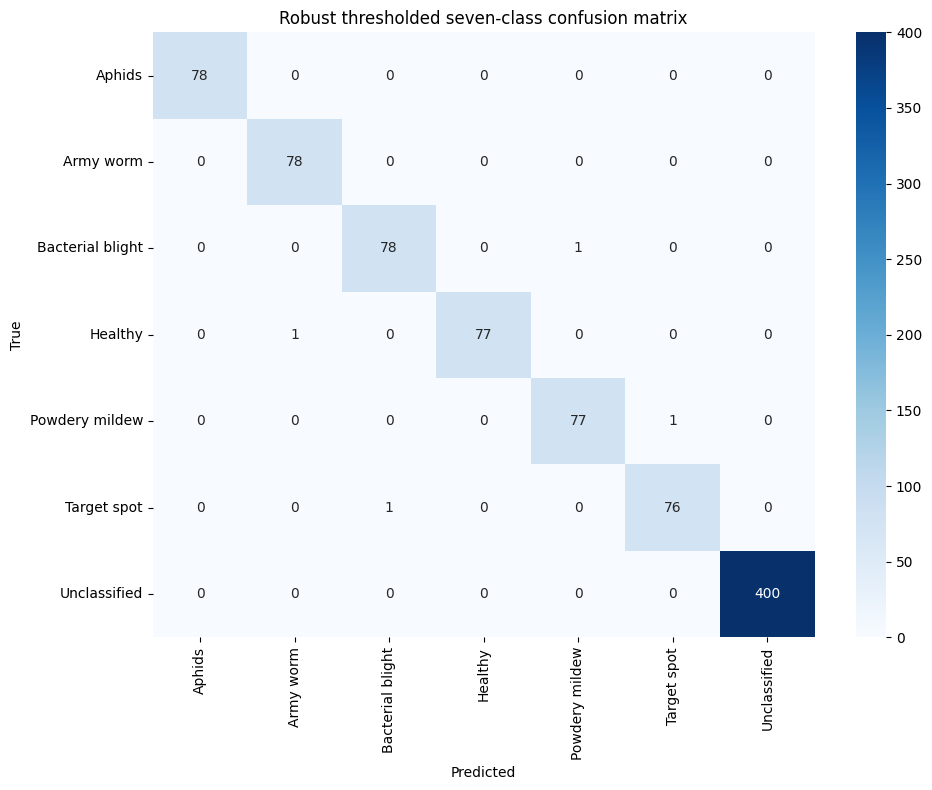

In [12]:
# Disease predictions.
test_prob=disease_model.predict(test_ds,verbose=0); test_true=test_df.label.to_numpy(); test_arg=test_prob.argmax(1); test_max=test_prob.max(1)
# Gate predictions aligned with gate_test manifest order.
gate_test_prob=gate_model.predict(gate_test_ds,verbose=0).ravel(); gate_true=gate_test.gate_label.to_numpy()
# Build a path-keyed gate prediction map to avoid any accidental ordering assumptions.
gate_map=dict(zip(gate_test.filepath,gate_test_prob)); gate_for_test=np.array([gate_map[p] for p in test_df.filepath])
final_pred=np.where(gate_for_test<GATE_THRESHOLD,UNKNOWN_INDEX,np.where(test_max<DISEASE_THRESHOLD,UNKNOWN_INDEX,test_arg))

raw_metrics={"raw_accuracy":accuracy_score(test_true,test_arg),"raw_balanced_accuracy":balanced_accuracy_score(test_true,test_arg),"raw_macro_f1":f1_score(test_true,test_arg,average="macro",zero_division=0),"thresholded_accuracy":accuracy_score(test_true,final_pred),"thresholded_balanced_accuracy":balanced_accuracy_score(test_true,final_pred),"thresholded_macro_f1":f1_score(test_true,final_pred,average="macro",zero_division=0)}
print(pd.Series(raw_metrics).round(4))
known_mask=test_df.source.to_numpy()=="cotton"; unknown_mask=~known_mask
open_metrics={"known_test_images":int(known_mask.sum()),"unknown_test_images":int(unknown_mask.sum()),"known_accuracy":accuracy_score(test_true[known_mask],final_pred[known_mask]),"known_false_rejection_rate":float(np.mean(final_pred[known_mask]==UNKNOWN_INDEX)),"unknown_rejection_rate":float(np.mean(final_pred[unknown_mask]==UNKNOWN_INDEX)),"gate_nonplant_rejection_rate":float(np.mean(gate_for_test[unknown_mask & (test_df.is_plant.to_numpy()==0)]<GATE_THRESHOLD)),"mean_known_gate_probability":float(gate_for_test[known_mask].mean()),"mean_known_disease_confidence":float(test_max[known_mask].mean())}
for source in sorted(test_df.source.unique()):
    m=test_df.source.to_numpy()==source; open_metrics[f"{source}_images"]=int(m.sum()); open_metrics[f"{source}_unclassified_rate"]=float(np.mean(final_pred[m]==UNKNOWN_INDEX))
print(pd.Series(open_metrics).round(4))
report=pd.DataFrame(classification_report(test_true,final_pred,target_names=CLASS_NAMES,output_dict=True,zero_division=0)).transpose(); display(report.round(4))
cm=confusion_matrix(test_true,final_pred,labels=np.arange(NUM_CLASSES)); plt.figure(figsize=(10,8)); sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=CLASS_NAMES,yticklabels=CLASS_NAMES); plt.title("Robust thresholded seven-class confusion matrix"); plt.xlabel("Predicted"); plt.ylabel("True"); plt.tight_layout(); plt.show()


## 12. Image-quality checks and safe inference

The quality gate rejects unreadable files, extremely small images, and near-uniform images before the neural models are called. This is not a complete leaf detector, but it prevents common invalid inputs from reaching the classifier.


In [13]:
def quality_check(image_path, min_side=32, uniform_std=3.0):
    try:
        with Image.open(image_path) as im:
            im=im.convert("RGB"); width,height=im.size; arr=np.asarray(im)
        if min(width,height)<min_side: return False,"too_small"
        if float(arr.std())<uniform_std: return False,"near_uniform"
        return True,"ok"
    except Exception: return False,"unreadable"

def robust_predict(image_path, gate=gate_model, disease=disease_model, gate_threshold=GATE_THRESHOLD, disease_threshold=DISEASE_THRESHOLD):
    ok,reason=quality_check(image_path)
    if not ok: return {"class":"Unclassified","reason":reason,"confidence":0.0}
    image=tf.io.read_file(str(image_path)); image=tf.image.decode_image(image,channels=3,expand_animations=False); image.set_shape([None,None,3]); image=tf.image.resize(image,IMAGE_SIZE,antialias=True); image=tf.cast(image,tf.float32)/255.
    batch=tf.expand_dims(image,0); plant_probability=float(gate(batch,training=False).numpy().ravel()[0])
    if plant_probability<gate_threshold: return {"class":"Unclassified","reason":"non_plant_gate","plant_probability":plant_probability,"confidence":plant_probability}
    probabilities=disease(batch,training=False).numpy()[0]; idx=int(probabilities.argmax()); confidence=float(probabilities[idx])
    if confidence<disease_threshold: return {"class":"Unclassified","reason":"low_disease_confidence","plant_probability":plant_probability,"model_top_class":CLASS_NAMES[idx],"confidence":confidence}
    return {"class":CLASS_NAMES[idx],"reason":"accepted","plant_probability":plant_probability,"confidence":confidence,"probabilities":dict(zip(CLASS_NAMES,probabilities.tolist()))}

# Example: print(robust_predict("/kaggle/working/example.jpg"))


## 13. Save all deployment artifacts


In [14]:
disease_model.save(WORKING_DIR/"cotton_efficientnetb0_robust_open_set.keras")
gate_model.save(WORKING_DIR/"plant_leaf_gate.keras")
train_df.to_csv(WORKING_DIR/"train_manifest.csv",index=False); val_df.to_csv(WORKING_DIR/"validation_manifest.csv",index=False); test_df.to_csv(WORKING_DIR/"test_manifest.csv",index=False); report.to_csv(WORKING_DIR/"classification_report.csv"); pd.DataFrame(cm,index=CLASS_NAMES,columns=CLASS_NAMES).to_csv(WORKING_DIR/"confusion_matrix.csv"); table.to_csv(WORKING_DIR/"disease_thresholds.csv"); gate_thresholds.to_csv(WORKING_DIR/"gate_thresholds.csv")
with open(WORKING_DIR/"robust_config.json","w") as f:
    json.dump({"class_names":CLASS_NAMES,"unknown_index":UNKNOWN_INDEX,"gate_threshold":GATE_THRESHOLD,"disease_threshold":DISEASE_THRESHOLD,"metrics":{**{k:float(v) for k,v in raw_metrics.items()},**{k:(float(v) if isinstance(v,(float,np.floating)) else int(v)) for k,v in open_metrics.items()}},"sources":["cifar10"]},f,indent=2)
print("Saved artifacts:",sorted(p.name for p in WORKING_DIR.iterdir()))


Saved artifacts: ['best_finetune.keras', 'best_head.keras', 'classification_report.csv', 'confusion_matrix.csv', 'cotton_efficientnetb0_robust_open_set.keras', 'disease_thresholds.csv', 'finetune.csv', 'gate_thresholds.csv', 'head.csv', 'plant_leaf_gate.keras', 'robust_config.json', 'test_manifest.csv', 'train_manifest.csv', 'unknown_sources', 'validation_manifest.csv']


## Experiment record and references

Record the supported and unknown source counts, gate and disease thresholds, frozen-head and fine-tuning epochs, known false-rejection rate, aggregate unknown-rejection rate, and source-specific rejection rates. A high overall score is not sufficient if the system rejects genuine cotton leaves or fails on one unknown subtype.

### References

1. [Keras CIFAR-10 loader](https://www.tensorflow.org/api_docs/python/tf/keras/datasets/cifar10/load_data)
2. [PlantDoc repository and CC-BY-4.0 link](https://github.com/pratikkayal/PlantDoc-Dataset)
3. [PlantDoc paper](https://arxiv.org/html/1911.10317v1)


# 14. Recorded results from this run

This section records the outputs from the executed run above. The results are based on the fixed random seed and the CIFAR-10 unknown-image source used in this notebook.

## Dataset and split sizes

| Partition | Cotton images | CIFAR-10 `Unclassified` images | Total |
|---|---:|---:|---:|
| Training | 3,840 | 800 | **4,640** |
| Validation | 480 | 400 | **880** |
| Test | 468 | 400 | **868** |

The CIFAR-10 unknown test set contained **252 animal images** and **148 object/vehicle images**. The unknown training set contained 483 animal images and 317 object/vehicle images; the validation set contained 234 animal images and 166 object/vehicle images. The supported cotton training classes contained 632–642 images per class after stratified splitting.

## Configuration used

| Component | Recorded setting |
|---|---|
| Random seed | `123` |
| Image size | `256 × 256 × 3` RGB |
| Batch size | `32` |
| Supported classes | Aphids, Army worm, Bacterial blight, Healthy, Powdery mildew, Target spot |
| Additional class | `Unclassified` |
| Unknown source | CIFAR-10 loaded through `keras.datasets.cifar10.load_data()` |
| Disease model | ImageNet-pretrained EfficientNetB0, `include_top=False` |
| Disease classifier | Global average pooling, BatchNormalization, Dropout `0.35`, Dense softmax with 7 outputs |
| Disease augmentation | Random horizontal flip, rotation `0.08`, zoom `±0.10`, translation `0.08`, contrast `0.15` |
| Disease preprocessing | Dataset tensors `[0, 1]`; rescaled to `[0, 255]` before EfficientNet’s built-in preprocessing |
| Disease head optimizer | Adam, learning rate `1e-3` |
| Fine-tuning optimizer | Adam, learning rate `1e-5` |
| Fine-tuning scope | Upper 40 EfficientNet layers considered; BatchNormalization layers kept frozen |
| Disease checkpoint metric | Validation macro-F1 across all seven classes |
| Disease early stopping | Patience `8` on validation macro-F1 |
| Learning-rate reduction | Factor `0.25`, patience `3`, minimum learning rate `1e-7` |
| Plant/leaf gate | ImageNet-pretrained MobileNetV3Small with sigmoid output |
| Gate optimizer | Adam, learning rate `1e-3` |
| Gate early stopping | Patience `3` on validation AUC |
| Quality checks | Unreadable image, minimum side `32` pixels, near-uniform standard deviation below `3.0` |

The notebook did not print Keras parameter totals in its recorded output, so exact parameter counts are intentionally not claimed here. The architecture and trainable-layer policy above are the authoritative configuration for this run.

## Training duration and best validation results

The plant/leaf gate trained for **4 of 12 maximum epochs**. It reached validation accuracy **1.0000** and validation AUC **1.0000** from epoch 2 onward. The gate rejection threshold selected from validation data was **0.57**. The threshold search required at least 98% plant acceptance; the displayed candidate thresholds achieved balanced accuracy 1.0000 on the gate validation set.

The EfficientNet disease model trained in two stages. The frozen-backbone head stage ran for **16 of 25 maximum epochs**. Its best recorded validation macro-F1 was **0.9893 at epoch 8**, with validation accuracy **0.9932** and validation loss **0.0317**. The fine-tuning stage ran for **20 of 35 maximum epochs**. Its best recorded validation macro-F1 was **0.9946 at epoch 12**, with validation accuracy **0.9966** and validation loss **0.0155**. In total, the run executed **40 model-training epochs across the gate, frozen disease head, and fine-tuning stages**.

The disease confidence threshold selected from validation data was **0.30**. At this threshold, known validation-image acceptance was **100%**, unknown validation-image rejection was **100%**, and validation macro-F1 was **0.9946**.

## Final test results

The final test set contained 468 supported cotton images and 400 CIFAR-10 unknown images. The raw seven-class prediction and the complete thresholded gate-plus-disease decision produced the same aggregate scores in this run.

| Metric | Result |
|---|---:|
| Raw seven-class accuracy | **0.9954** |
| Thresholded seven-class accuracy | **0.9954** |
| Balanced accuracy | **0.9927** |
| Macro precision | **0.9927** |
| Macro recall | **0.9927** |
| Macro-F1 | **0.9927** |
| Weighted precision | **0.9954** |
| Weighted recall | **0.9954** |
| Weighted-F1 | **0.9954** |

The complete decision pipeline classified **464 of 468 cotton test images correctly**, giving known-cotton accuracy of **0.9915**. The known-image false-rejection rate was **0.0000**, meaning no genuine cotton test image was sent to `Unclassified` by the gate or confidence rule.

All **400 of 400 CIFAR-10 unknown test images** were returned as `Unclassified`, giving an unknown-rejection rate of **1.0000**. The plant/non-plant gate itself rejected **399 of 400 non-plant test images**, a non-plant gate rejection rate of **0.9975**. The final end-to-end decision rejected all 400 unknown images because the complete system also includes the disease-model `Unclassified` output and confidence rule.

The mean plant-gate probability for genuine cotton test images was **0.9891**, and the mean maximum disease-model confidence for genuine cotton test images was **0.9855**. Source-specific final `Unclassified` rates were 0.0000 for cotton and 1.0000 for CIFAR-10.

## Per-class test report

| Class | Precision | Recall | F1-score | Support |
|---|---:|---:|---:|---:|
| Aphids | 1.0000 | 1.0000 | 1.0000 | 78 |
| Army worm | 0.9873 | 1.0000 | 0.9936 | 78 |
| Bacterial blight | 0.9873 | 0.9873 | 0.9873 | 79 |
| Healthy | 1.0000 | 0.9872 | 0.9935 | 78 |
| Powdery mildew | 0.9872 | 0.9872 | 0.9872 | 78 |
| Target spot | 0.9870 | 0.9870 | 0.9870 | 77 |
| Unclassified | 1.0000 | 1.0000 | 1.0000 | 400 |

## Interpretation and limitations

This run demonstrates excellent performance on the constructed test split: very high supported-class performance, no false rejection of the 468 cotton test images, and complete rejection of the 400 CIFAR-10 unknown images. However, the unknown set contains only low-resolution CIFAR-10 animals and objects. It does not establish rejection performance for high-resolution people, hands, soil, tools, buildings, arbitrary photographs, other plant leaves, or flowers.

The `Unclassified` result should therefore be interpreted as **validated for the CIFAR-10 unknown distribution**, not as a guarantee for every possible image outside the six cotton categories. For deployment, add a separate held-out evaluation set containing high-resolution non-plant photographs and non-cotton plant leaves, then recalibrate the gate and disease thresholds without using the final test set.

The saved deployment artifacts from this run were `cotton_efficientnetb0_robust_open_set.keras`, `plant_leaf_gate.keras`, `robust_config.json`, the train/validation/test manifests, both threshold tables, the classification report, and the confusion matrix.
